In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.display import HTML
from scipy.optimize import curve_fit
from scipy.optimize import differential_evolution
import warnings
import math

In [110]:
def read_and_process_csv(file_path):

#Read the specific csv file as pandas dataframe and eliminate the data points less than 5
    df = pd.read_csv(file_path)
    df.replace({"JAN": "01", "FEB": "02", "MAR":"03", "APR":"04", "MAY":"05", "JUN":"06", "JUL":"07",
               "AUG":"08", "SEP":"09", "OCT":"10", "NOV":"11", "DEC":"12"}, inplace=True)
    
    df = df.sort_values(['year', 'month'])
    #display(HTML(df.to_html()))
    time_series = []
    current_time = 0
    max_time = 0
    for index, row in df.iterrows():
        #print(row)
        time_string = str(row['year']) + str(row['month'])
        time_int = int(time_string)
        if max_time == 0:
            max_time = time_int
            time_series.append(current_time)
        elif time_int > max_time:
            max_time = time_int
            current_time = current_time + 1
            time_series.append(current_time)            
        else:
            time_series.append(current_time)
        
    #print(time_series)
    df['time'] = time_series
    
    return df
    


In [111]:
def delete_invalid_data():
    df1 = df.groupby("API").size()
    invalid_api_list = []
    for api, count in df1.items():
        if count<=5:
            invalid_api_list.append(str(api))
    for api in invalid_api_list:
        df.drop(df.loc[df['API']==api].index, inplace=True)

In [112]:
df=read_and_process_csv("Project_data.csv")
delete_invalid_data()
display(HTML(df.to_html()))

,API,year,month,oil,time
2619,A_30015424560000,2014,12,1258,0
472,A_30015420910000,2015,01,24072,1
797,A_30015421750000,2015,01,1948,1
1023,A_30015422260000,2015,01,1870,1
1122,A_30015422470000,2015,01,0,1
1275,A_30015422850000,2015,01,8998,1
1500,A_30015423250000,2015,01,1722,1
1541,A_30015423270000,2015,01,690,1
1771,A_30015423700000,2015,01,2014,1
2078,A_30015424140000,2015,01,3735,1


In [ ]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['oil'])
plt.show()

In [ ]:
sns.boxplot(df['oil'])

In [ ]:
new_df_cap = df.copy()
new_df_cap['oil'] = np.where(
    new_df_cap['oil'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['oil'] < lower_limit,
        lower_limit,
        new_df_cap['oil']
    )
)



In [113]:
tArray = df['time'].to_numpy()
yArray = df['oil'].to_numpy()


In [114]:
def decline_curve_model(tArray, q0, q1, D0, D1, b, t1):
    returnArray = []
    for t in tArray:
        if t < t1:
            returnArray.append(q0 * math.exp(D0 * t))
        else:
            returnArray.append(q1/math.pow(1 + b * D1 * (t - t1), 1/b))
    return returnArray
    

In [115]:
def sumOfSquaredError(parameterTuple):
    warnings.filterwarnings("ignore") # do not print warnings
    val = decline_curve_model(tArray, *parameterTuple)
    return np.sum((yArray - val) ** 2.0)


In [136]:
def generate_Parameters():
    # min and max used for bounds
    maxT = max(tArray)
    minT = min(tArray)
    maxY = max(yArray)
    minY = min(yArray)

    parameterBounds = []
    parameterBounds.append([0, 1]) # search bounds for q0
    parameterBounds.append([0, 1]) # search bounds for q1
    parameterBounds.append([0, 1]) # search bounds for D0
    parameterBounds.append([0, 1]) # search bounds for D1
    parameterBounds.append([0.01, 1]) # search bounds for b
    parameterBounds.append([minT, maxT]) # search bounds for t1

    result = differential_evolution(sumOfSquaredError, parameterBounds, seed=3)
    return result.x


In [137]:

FittedParameters = generate_Parameters()

In [138]:
print('Parameters:', FittedParameters)

Parameters: [ 0.99735528  0.96748834  0.84982556  0.44993492  0.20376652 11.31805281]


In [139]:
df1 = df.groupby("API").size()
valid_api_list = []
for api, count in df1.items():
        valid_api_list.append(str(api))
print(valid_api_list)

['A_30015420120000', 'A_30015420140000', 'A_30015420220000', 'A_30015420300000', 'A_30015420320000', 'A_30015420340000', 'A_30015420370000', 'A_30015420590000', 'A_30015420610000', 'A_30015420620000', 'A_30015420710000', 'A_30015420720000', 'A_30015420730000', 'A_30015420780000', 'A_30015420910000', 'A_30015420920000', 'A_30015420980000', 'A_30015421050000', 'A_30015421130000', 'A_30015421310000', 'A_30015421390000', 'A_30015421410000', 'A_30015421500000', 'A_30015421610000', 'A_30015421660000', 'A_30015421700000', 'A_30015421720000', 'A_30015421730000', 'A_30015421750000', 'A_30015421800000', 'A_30015421810000', 'A_30015421820000', 'A_30015421860000', 'A_30015421880000', 'A_30015422120000', 'A_30015422230000', 'A_30015422240000', 'A_30015422260000', 'A_30015422360000', 'A_30015422380000', 'A_30015422470000', 'A_30015422640000', 'A_30015422700000', 'A_30015422730000', 'A_30015422810000', 'A_30015422850000', 'A_30015422900000', 'A_30015422910000', 'A_30015422930000', 'A_30015423120000',

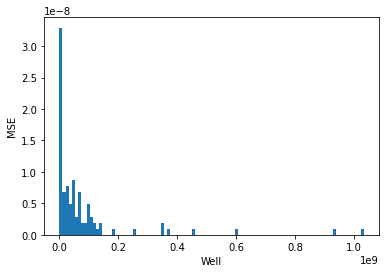

In [151]:
MSE_list = []
for api in valid_api_list:
    tArray = df.loc[df['API'] == api]['time'].to_numpy()
    yArray = df.loc[df['API'] == api]['oil'].to_numpy()
    modelPredictions = decline_curve_model(tArray, *FittedParameters) 
    absError = modelPredictions - yArray

    SE = np.square(absError) # squared errors
    MSE = np.mean(SE) # mean squared errors
    MSE_list.append(MSE)
    RMSE = np.sqrt(MSE) # Root Mean Squared Error, RMSE
    Rsquared = 1.0 - (np.var(absError) / np.var(yArray))
    

#print(MSE_list)
plt.hist(MSE_list, density=True, bins=99)  # density=False would make counts
plt.ylabel('MSE')
plt.xlabel('Well');
    

In [133]:
tArray = df.loc[df['API'] == 'A_30015420220000']['time'].to_numpy()
yArray = df.loc[df['API'] == 'A_30015420220000']['oil'].to_numpy()
print(tArray)
print(yArray)

[ 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32
 33 34 35 36 37 38 39 40 41]
[  249 10850  9420  6460  6523  6897  5670  2805  2004  1384  2040  1983
  1289  1718  1504   479   364   956   852   499   313  1617  1406   963
  1262  1116  1195  1050  1077   908  1016   863   870]


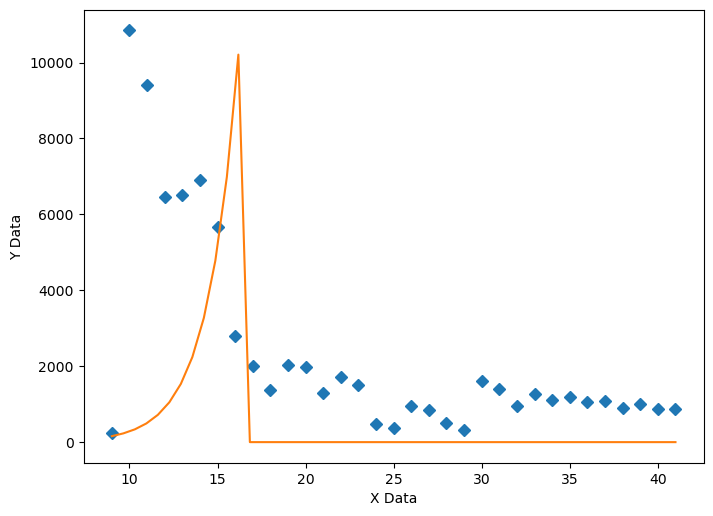

In [134]:
##########################################################
# graphics output section
def ModelAndScatterPlot(graphWidth, graphHeight):
    f = plt.figure(figsize=(graphWidth/100.0, graphHeight/100.0), dpi=100)
    axes = f.add_subplot(111)

    # first the raw data as a scatter plot
    axes.plot(tArray, yArray,  'D')

    # create data for the fitted equation plot
    xModel = np.linspace(min(tArray), max(tArray))
    yModel = decline_curve_model(xModel, *FittedParameters)

    # now the model as a line plot
    axes.plot(xModel, yModel)

    axes.set_xlabel('Time') # X axis data label
    axes.set_ylabel('Oil') # Y axis data label

    plt.show()
    plt.close('all') # clean up after using pyplot

graphWidth = 800
graphHeight = 600
ModelAndScatterPlot(graphWidth, graphHeight)